# Vision Transformers

> **Original Paper:** *An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale
Dosovitskiy* (et al., ICLR 2021)
> https://arxiv.org/abs/2010.11929
>
> <br/>
>
> **Google Research implementation:**  
> https://github.com/google-research/vision_transformer

## Importing the libraries

In [ ]:
import os
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix

## Loading CIFAR10 dataset from kaggle

In [ ]:
path = kagglehub.dataset_download("swaroopkml/cifar10-pngs-in-folders")
print("Path to dataset files:", path)

100%|██████████| 140M/140M [00:00<00:00, 236MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/swaroopkml/cifar10-pngs-in-folders/versions/1


In [ ]:
train_dir = os.path.join(path, "cifar10", "cifar10", "train")
test_dir = os.path.join(path, "cifar10","cifar10", "test")

In [ ]:
IMG_SIZE = (32, 32)

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size = IMG_SIZE,
    batch_size = None,
    shuffle = True
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size = IMG_SIZE,
    batch_size = None,
    shuffle = False
)

Found 50000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.


## Converting into numpy array

In [ ]:
X_train = []
y_train = []

for image, label in train_dataset:
    X_train.append(image.numpy())
    y_train.append(label.numpy())

X_train = np.array(X_train)
y_train = np.array(y_train)

In [ ]:
X_test = []
y_test = []

for image, label in test_dataset:
    X_test.append(image.numpy())
    y_test.append(label.numpy())

X_test = np.array(X_test)
y_test = np.array(y_test)

In [ ]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(50000,)
(10000, 32, 32, 3)
(10000,)


## Normalizing the images

In [ ]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

## Defining Class Names

In [ ]:
classes = ["Airplane", "Automobile", "Bird", "Cat", "Deer", "Dog", "Frog", "Horse", "Ship","Truck"]

## Visualising the images

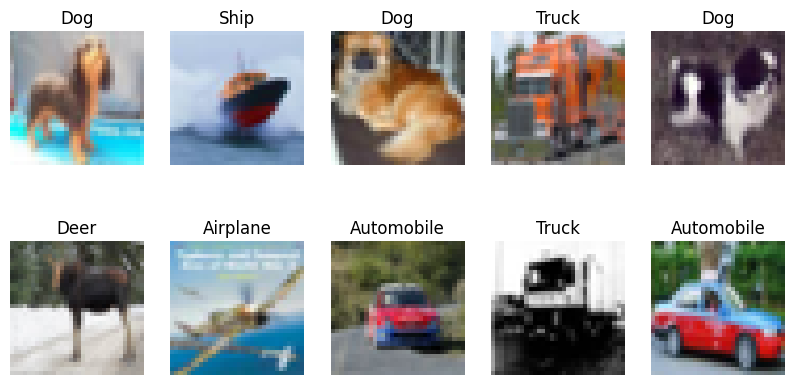

In [ ]:
plt.figure(figsize = (10, 5))

for i in range(10):

    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(classes[y_train[i]])
    plt.axis("off")

plt.show()

## Creating Patches Layer

In [ ]:
class Patches(layers.Layer):

    def __init__(self, patch_size):

        super().__init__()
        self.patch_size = patch_size

    def call(self, images):

        batch_size = tf.shape(images)[0]

        patches = tf.image.extract_patches(
            images = images,
            sizes = [1, self.patch_size, self.patch_size, 1],
            strides = [1 ,self.patch_size, self.patch_size, 1],
            rates = [1, 1, 1, 1],
            padding = "VALID"
        )

        patch_dims = patches.shape[-1]

        patches = tf.reshape(
            patches,
            [batch_size, -1, patch_dims]
        )

        return patches

## Testing Patches Layer

In [ ]:
patch_layer = Patches(4)
patches = patch_layer(X_train[:1])
print(patches.shape)

(1, 64, 48)


## Patch Encoder Layer

In [ ]:
class PatchEncoder(layers.Layer):

    def __init__(self, num_patches, projection_dim):

        super().__init__()

        self.projection = layers.Dense(
            projection_dim
        )

        self.position_embedding = layers.Embedding(
            input_dim = num_patches,
            output_dim = projection_dim
        )

        self.num_patches = num_patches

    def call(self, patches):

        positions = tf.range(
            start = 0,
            limit = self.num_patches
        )

        encoded = self.projection(
            patches
        )

        encoded += self.position_embedding(
            positions
        )

        return encoded

## MLP Layer

In [ ]:
def mlp(x, hidden_units, dropout_rate):

    for units in hidden_units:

        x = layers.Dense(
            units,
            activation = "gelu"
        )(x)

        x = layers.Dropout(
            dropout_rate
        )(x)

    return x

## Initialising Parameters

In [ ]:
image_size = 32
patch_size = 4

num_patches = (image_size // patch_size) ** 2
projection_dim = 64
num_heads = 4

transformer_units = [128, 64]
transformer_layers = 4

num_classes = 10

## Input Layer

In [ ]:
inputs = layers.Input(
    shape = (32, 32, 3)
)

## Data Augmentation Layer

In [ ]:
x = layers.RandomFlip("horizontal")(inputs)
x = layers.RandomRotation(0.1)(x)
x = layers.RandomZoom(0.1)(x)

## Creating Patches

In [ ]:
patches = Patches(
    patch_size
)(inputs)

## Encoding Patches

In [ ]:
encoded = PatchEncoder(
    num_patches,
    projection_dim
)(patches)

## Creating Transformer Encoder

In [ ]:
for _ in range(transformer_layers):

    x1 = layers.LayerNormalization(
        epsilon = 1e-6
    )(encoded)

    attention_output = layers.MultiHeadAttention(
        num_heads = num_heads,
        key_dim = projection_dim
    )(x1,x1)

    x2 = layers.Add()([
        attention_output,
        encoded
    ])

    x3 = layers.LayerNormalization(
        epsilon = 1e-6
    )(x2)

    x3 = mlp(
        x3,
        transformer_units,
        0.1
    )

    encoded = layers.Add()([
        x3,
        x2
    ])

## Creating Classification Head

In [ ]:
representation = layers.LayerNormalization(
    epsilon = 1e-6
)(encoded)

In [ ]:
representation = layers.Flatten()(
    representation
)

In [ ]:
representation = layers.Dropout(
    0.5
)(representation)

In [ ]:
features = layers.Dense(
    256,
    activation = "gelu"
)(representation)

In [ ]:
features = layers.Dropout(
    0.5
)(features)

In [ ]:
outputs = layers.Dense(
    num_classes,
    activation = "softmax"
)(features)

## Creating the model

In [ ]:
model = Model(
    inputs,
    outputs
)

## Getting model summary

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches_1 (Patches) │ (None, None, 48)  │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, 64, 64)    │      7,232 │ patches_1[0][0]   │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 64, 64)    │        128 │ patch_encoder[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64)    │          0 │ multi_head_atten… │
│                     │                   │            │ patch_encoder[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 128)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64, 64)    │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64, 64)    │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 64)    │          0 │ dropout_2[0][0],  │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 64, 64)    │          0 │ multi_head_atten… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64, 128)   │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64, 64)    │      8,256 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,391,562 (5.31 MB)

 Trainable params: 1,391,562 (5.31 MB)

 Non-trainable params: 0 (0.00 B)

## Compiling the transformer

In [ ]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 3e-4),
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

## Fitting the transformer to the training set

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_split = 0.1,
    epochs = 10,
    batch_size = 64,
    shuffle = True
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 40ms/step - accuracy: 0.1765 - loss: 2.1631 - val_accuracy: 0.2912 - val_loss: 1.8541
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.2863 - loss: 1.8620 - val_accuracy: 0.3988 - val_loss: 1.6437
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.3689 - loss: 1.6907 - val_accuracy: 0.4528 - val_loss: 1.5053
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.4138 - loss: 1.5835 - val_accuracy: 0.5094 - val_loss: 1.3695
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - accuracy: 0.4539 - loss: 1.5013 - val_accuracy: 0.5278 - val_loss: 1.3125
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.4826 - loss: 1.4382 - val_accuracy: 0.5526 - val_loss: 1.2661
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.5054 - loss: 1.3707 - val_accuracy: 0.5600 - val_loss: 1.2258
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.5266 - loss: 1.3250 - 

## Evaluating the transformer

In [ ]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5978 - loss: 1.1292


In [ ]:
print("Accuracy :", accuracy)

Accuracy : 0.5978000164031982


## Predicting the test set

In [ ]:
predictions = model.predict(X_test)
predictions = np.argmax(
    predictions,
    axis = 1
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step


## Making the confusion matrix

In [ ]:
actual = y_test.flatten()

In [ ]:
cm = confusion_matrix(actual, predictions)
print(cm)

[[651  36  49  31   9  10  21  30  64  99]
 [ 20 718   5  18   1   7   7  16  11 197]
 [ 87  10 411  82 135  98  93  56  10  18]
 [ 21   8  55 406  55 279  79  49  16  32]
 [ 34   8  95  73 480  68  93 127  10  12]
 [  8   6  44 220  75 521  19  92   1  14]
 [  7  14  51 115  83  22 679  15   3  11]
 [ 13   6  23  50  55  87   8 713   3  42]
 [109  72  10  24  11  11   5  16 663  79]
 [ 26 144   5  14   0   4  11  40  20 736]]


## Predicting new images

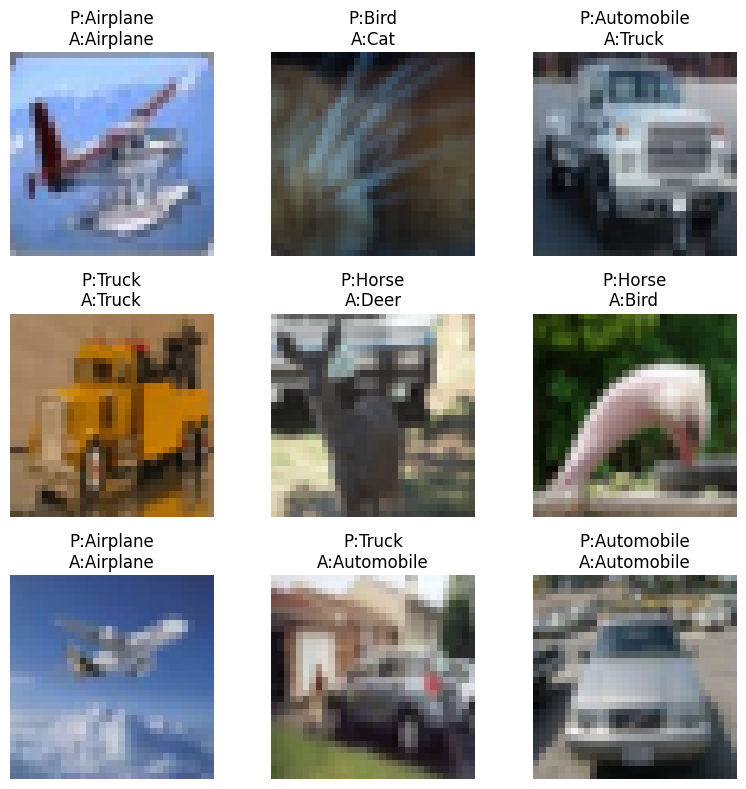

In [ ]:
plt.figure(figsize = (8, 8))

indices = np.random.choice(
    len(X_test),
    9,
    replace = False
)

for i, index in enumerate(indices):

    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[index])
    plt.title(f"P:{classes[predictions[index]]}\nA:{classes[actual[index]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()